<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/antibiotic_resistance_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("antibiotic_resistance_tracking.csv")

# Check top 5 rows
print(df.head())


  Patient_ID  Age  Gender Specimen_Type   Amoxicillin Ciprofloxacin  \
0      P0001   36  Female         Blood  Intermediate     Sensitive   
1      P0002   59  Female         Blood  Intermediate     Resistant   
2      P0003   13  Female         Urine  Intermediate     Sensitive   
3      P0004    4  Female        Sputum  Intermediate     Resistant   
4      P0005   51    Male         Urine     Resistant     Sensitive   

      Meropenem    Vancomycin      Colistin       Test_Method  \
0  Intermediate  Intermediate  Intermediate  Automated System   
1  Intermediate     Sensitive  Intermediate               MIC   
2     Resistant  Intermediate     Resistant               MIC   
3     Sensitive  Intermediate  Intermediate  Automated System   
4     Resistant  Intermediate  Intermediate  Automated System   

  Resistance_Genes    Outcome  
0              KPC        ICU  
1              KPC  Recovered  
2           OXA-48        ICU  
3           OXA-48        ICU  
4              NaN    

In [147]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Specimen_Type', 'Amoxicillin',
       'Ciprofloxacin', 'Meropenem', 'Vancomycin', 'Colistin', 'Test_Method',
       'Resistance_Genes', 'Outcome'],
      dtype='object')

In [148]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        2199 non-null   object
 1   Age               2200 non-null   int64 
 2   Gender            2200 non-null   object
 3   Specimen_Type     2200 non-null   object
 4   Amoxicillin       2200 non-null   object
 5   Ciprofloxacin     2200 non-null   object
 6   Meropenem         2200 non-null   object
 7   Vancomycin        2200 non-null   object
 8   Colistin          2200 non-null   object
 9   Test_Method       2200 non-null   object
 10  Resistance_Genes  1763 non-null   object
 11  Outcome           2200 non-null   object
dtypes: int64(1), object(11)
memory usage: 206.4+ KB
None
Patient_ID            1
Age                   0
Gender                0
Specimen_Type         0
Amoxicillin           0
Ciprofloxacin         0
Meropenem             0
Vancomycin            0

In [149]:
mapping = {
    "Sensitive": 0,
    "Intermediate": 1,
    "Resistant": 2
}

antibiotics = [
    "Amoxicillin",
    "Ciprofloxacin",
    "Meropenem",
    "Vancomycin",
    "Colistin"
]

for col in antibiotics:
    df[col] = df[col].map(mapping)

print(df.head())

  Patient_ID  Age  Gender Specimen_Type  Amoxicillin  Ciprofloxacin  \
0      P0001   36  Female         Blood            1              0   
1      P0002   59  Female         Blood            1              2   
2      P0003   13  Female         Urine            1              0   
3      P0004    4  Female        Sputum            1              2   
4      P0005   51    Male         Urine            2              0   

   Meropenem  Vancomycin  Colistin       Test_Method Resistance_Genes  \
0          1           1         1  Automated System              KPC   
1          1           0         1               MIC              KPC   
2          2           1         2               MIC           OXA-48   
3          0           1         1  Automated System           OXA-48   
4          2           1         1  Automated System              NaN   

     Outcome  
0        ICU  
1  Recovered  
2        ICU  
3        ICU  
4        ICU  


In [150]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Specimen_Type'] = le.fit_transform(df['Specimen_Type'])
df['Test_Method'] = le.fit_transform(df['Test_Method'])
df['Resistance_Genes'] = le.fit_transform(df['Resistance_Genes'])
df['Outcome'] = le.fit_transform(df['Outcome'])

In [151]:
X = df.drop(['Patient_ID','Amoxicillin'], axis=1)
y = df['Amoxicillin']

In [152]:
X = df.drop(['Patient_ID','Ciprofloxacin'], axis=1)
y = df['Ciprofloxacin']

In [153]:
X = df.drop(['Patient_ID','Resistance_Genes'], axis=1)
y = df['Resistance_Genes']

In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

targets = [
    "Outcome",
    "Amoxicillin",
    "Ciprofloxacin",
    "Resistance_Genes"
]

for target in targets:

    X = df.drop(["Patient_ID", target], axis=1)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(target, "Accuracy:", accuracy_score(y_test, y_pred))

Outcome Accuracy: 0.28863636363636364
Amoxicillin Accuracy: 0.32272727272727275
Ciprofloxacin Accuracy: 0.32045454545454544
Resistance_Genes Accuracy: 0.22727272727272727


In [155]:
print(df.nunique())

Patient_ID          2023
Age                   90
Gender                 2
Specimen_Type          5
Amoxicillin            3
Ciprofloxacin          3
Meropenem              3
Vancomycin             3
Colistin               3
Test_Method            3
Resistance_Genes       5
Outcome                3
dtype: int64


## Antibiotic Resistance Analysis (EDA)

### Resistance Genes vs Outcome

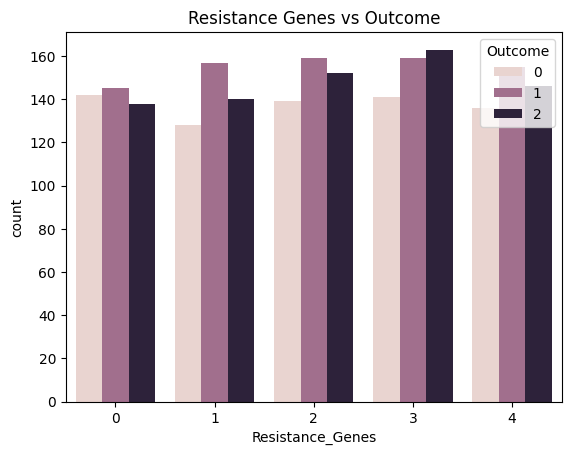

In [156]:
sns.countplot(x='Resistance_Genes', hue='Outcome', data=df)
plt.title("Resistance Genes vs Outcome")
plt.show()

##  Most Resistant Antibiotic

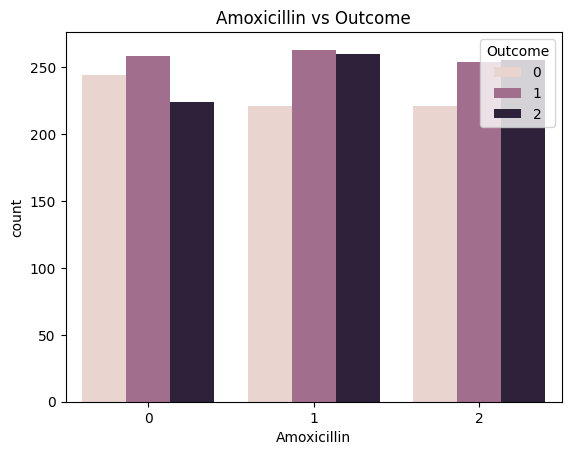

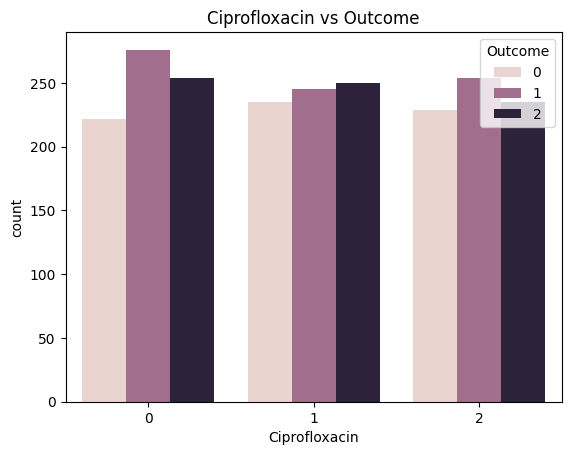

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Amoxicillin', hue='Outcome', data=df)
plt.title("Amoxicillin vs Outcome")
plt.show()

sns.countplot(x='Ciprofloxacin', hue='Outcome', data=df)
plt.title("Ciprofloxacin vs Outcome")
plt.show()

### Resistance Genes Distribution

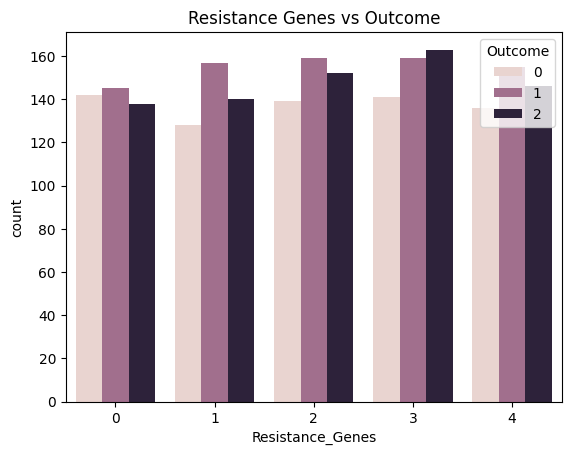

In [158]:
sns.countplot(x='Resistance_Genes', hue='Outcome', data=df)
plt.title("Resistance Genes vs Outcome")
plt.show()

### Correlation Heatmap

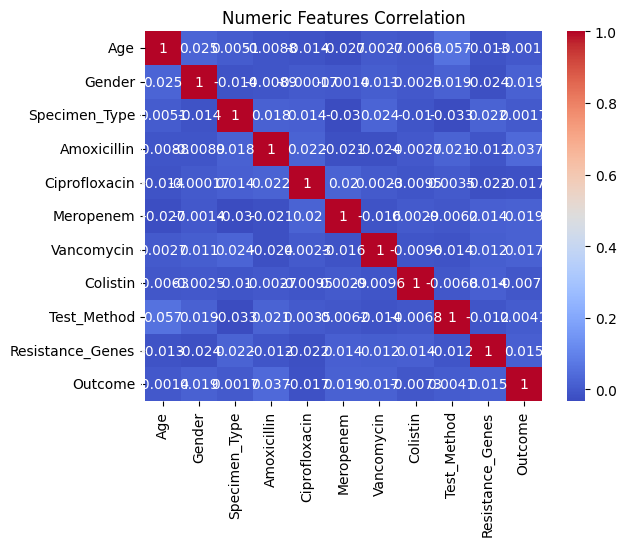

In [159]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Numeric Features Correlation")
plt.show()

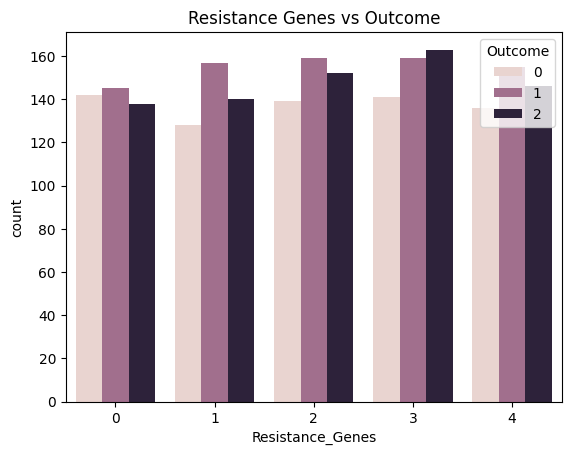

In [160]:
sns.countplot(x='Resistance_Genes', hue='Outcome', data=df)
plt.title("Resistance Genes vs Outcome")
plt.show()

In [161]:
from sklearn.ensemble import RandomForestClassifier

# Example: predict Amoxicillin resistance
X = df.drop(['Patient_ID','Amoxicillin'], axis=1, errors='ignore')
y = df['Amoxicillin']

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X, y)

# Feature importance
import pandas as pd
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance)

Age                 0.275352
Resistance_Genes    0.118835
Specimen_Type       0.116098
Ciprofloxacin       0.076407
Vancomycin          0.076285
Colistin            0.074945
Meropenem           0.074474
Test_Method         0.073188
Outcome             0.071365
Gender              0.043050
dtype: float64


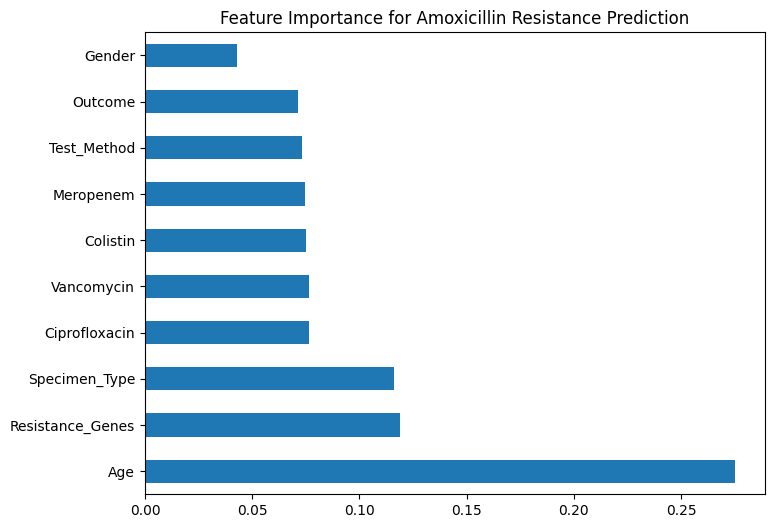

In [162]:
import matplotlib.pyplot as plt
importance.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance for Amoxicillin Resistance Prediction")
plt.show()

In [163]:
# Map Male=0, Female=1
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

In [164]:
# Identify remaining object/string columns
string_cols = df.select_dtypes(include='object').columns

# Convert them to numeric using one-hot encoding
df = pd.get_dummies(df, columns=string_cols)

In [165]:
print(df.columns)

Index(['Age', 'Gender', 'Specimen_Type', 'Amoxicillin', 'Ciprofloxacin',
       'Meropenem', 'Vancomycin', 'Colistin', 'Test_Method',
       'Resistance_Genes',
       ...
       'Patient_ID_P2014', 'Patient_ID_P2015', 'Patient_ID_P2016',
       'Patient_ID_P2017', 'Patient_ID_P2018', 'Patient_ID_P2019',
       'Patient_ID_P2020', 'Patient_ID_P2021', 'Patient_ID_P2022',
       'Patient_ID_P2023'],
      dtype='object', length=2034)


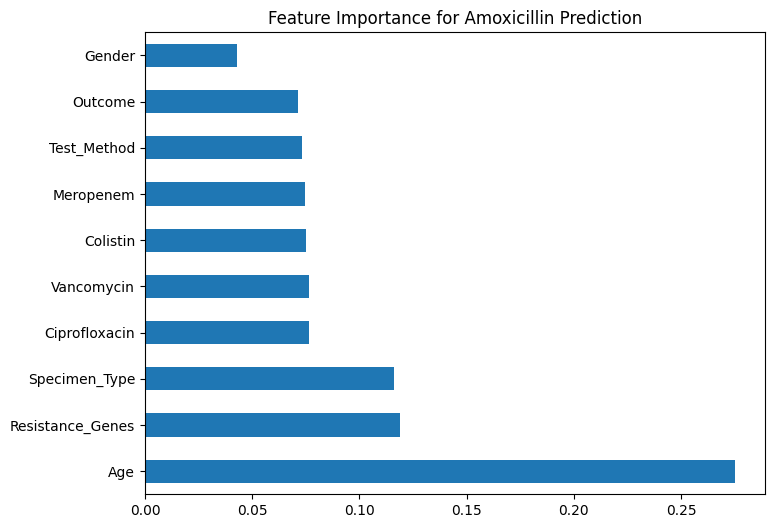

In [166]:
import matplotlib.pyplot as plt
importance.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance for Amoxicillin Prediction")
plt.show()


=== Amoxicillin Prediction ===
Accuracy: 0.318
              precision    recall  f1-score   support

           0       0.31      0.34      0.32       142
           1       0.31      0.30      0.30       144
           2       0.34      0.32      0.33       154

    accuracy                           0.32       440
   macro avg       0.32      0.32      0.32       440
weighted avg       0.32      0.32      0.32       440


Feature Importance:
 Age                             0.442129
Gender                          0.072630
Resistance_Genes_VIM            0.037469
Resistance_Genes_KPC            0.036896
Resistance_Genes_NDM-1          0.036325
Resistance_Genes_OXA-48         0.034449
Test_Method_Disc Diffusion      0.033056
Outcome_ICU                     0.032714
Test_Method_MIC                 0.032416
Test_Method_Automated System    0.031679
Outcome_Recovered               0.031025
Specimen_Type_Stool             0.030796
Specimen_Type_Urine             0.030708
Outcome_Deceased

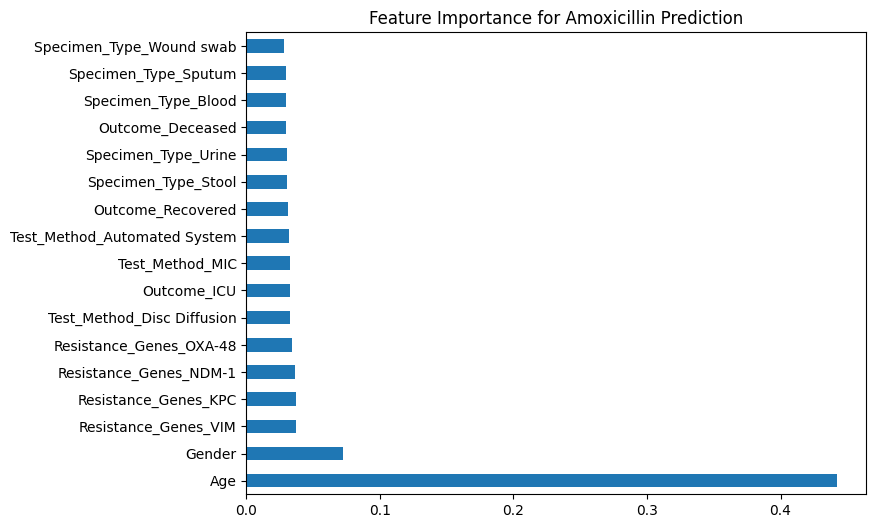


=== Ciprofloxacin Prediction ===
Accuracy: 0.332
              precision    recall  f1-score   support

           0       0.32      0.32      0.32       152
           1       0.33      0.30      0.32       145
           2       0.35      0.37      0.36       143

    accuracy                           0.33       440
   macro avg       0.33      0.33      0.33       440
weighted avg       0.33      0.33      0.33       440


Feature Importance:
 Age                             0.442954
Gender                          0.072158
Resistance_Genes_VIM            0.037298
Resistance_Genes_OXA-48         0.035437
Resistance_Genes_NDM-1          0.034954
Test_Method_Disc Diffusion      0.034925
Test_Method_Automated System    0.034680
Outcome_ICU                     0.034404
Outcome_Recovered               0.033936
Resistance_Genes_KPC            0.032402
Test_Method_MIC                 0.031810
Outcome_Deceased                0.031687
Specimen_Type_Blood             0.030536
Specimen_Type_

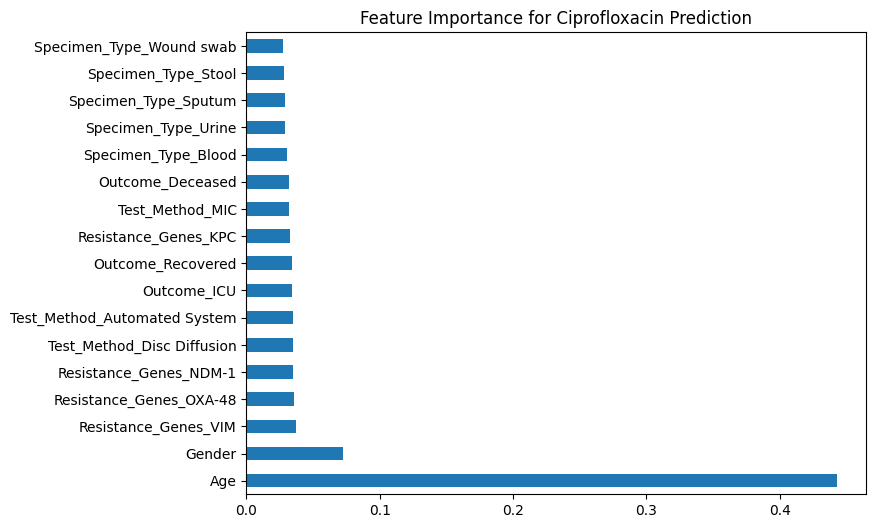


=== Meropenem Prediction ===
Accuracy: 0.334
              precision    recall  f1-score   support

           0       0.31      0.32      0.32       145
           1       0.37      0.40      0.39       149
           2       0.31      0.28      0.30       146

    accuracy                           0.33       440
   macro avg       0.33      0.33      0.33       440
weighted avg       0.33      0.33      0.33       440


Feature Importance:
 Age                             0.443627
Gender                          0.074113
Resistance_Genes_OXA-48         0.037760
Resistance_Genes_VIM            0.037306
Resistance_Genes_NDM-1          0.036463
Resistance_Genes_KPC            0.036268
Test_Method_Disc Diffusion      0.035256
Test_Method_Automated System    0.034461
Test_Method_MIC                 0.033935
Outcome_ICU                     0.033867
Outcome_Recovered               0.033601
Outcome_Deceased                0.033560
Specimen_Type_Stool             0.027856
Specimen_Type_Sput

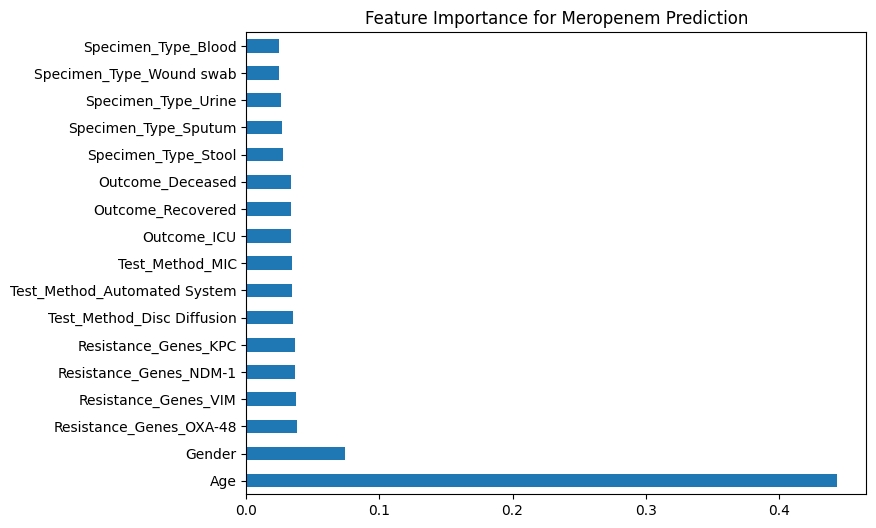


=== Vancomycin Prediction ===
Accuracy: 0.32
              precision    recall  f1-score   support

           0       0.36      0.41      0.38       147
           1       0.26      0.24      0.25       143
           2       0.33      0.31      0.32       150

    accuracy                           0.32       440
   macro avg       0.32      0.32      0.32       440
weighted avg       0.32      0.32      0.32       440


Feature Importance:
 Age                             0.442126
Gender                          0.073620
Resistance_Genes_NDM-1          0.037567
Resistance_Genes_OXA-48         0.036345
Outcome_Deceased                0.036243
Outcome_Recovered               0.036025
Resistance_Genes_KPC            0.035469
Outcome_ICU                     0.034973
Resistance_Genes_VIM            0.034298
Test_Method_Disc Diffusion      0.032310
Test_Method_MIC                 0.032039
Test_Method_Automated System    0.030645
Specimen_Type_Sputum            0.028811
Specimen_Type_Bloo

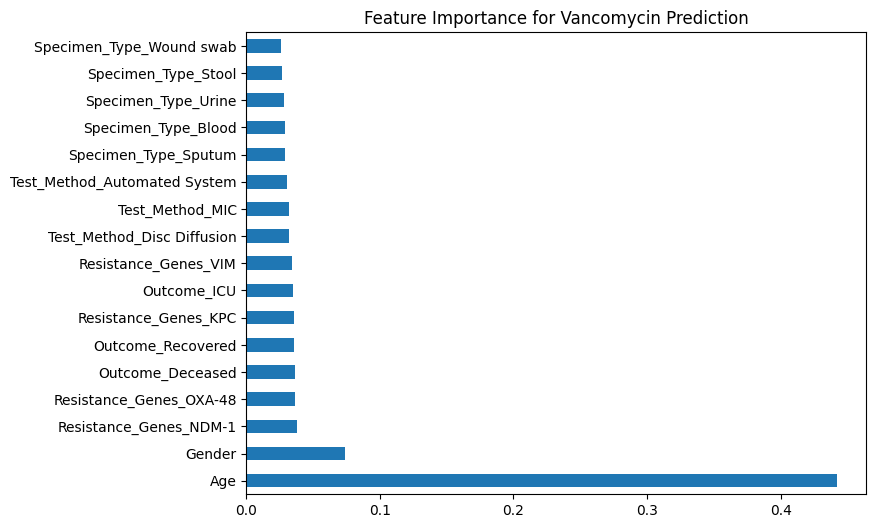


=== Colistin Prediction ===
Accuracy: 0.341
              precision    recall  f1-score   support

           0       0.35      0.37      0.36       143
           1       0.26      0.23      0.24       140
           2       0.39      0.41      0.40       157

    accuracy                           0.34       440
   macro avg       0.33      0.34      0.34       440
weighted avg       0.34      0.34      0.34       440


Feature Importance:
 Age                             0.449999
Gender                          0.072120
Resistance_Genes_KPC            0.036301
Resistance_Genes_VIM            0.036295
Resistance_Genes_OXA-48         0.036222
Test_Method_Automated System    0.034951
Test_Method_MIC                 0.034745
Outcome_ICU                     0.034716
Outcome_Deceased                0.034538
Test_Method_Disc Diffusion      0.034344
Outcome_Recovered               0.032717
Resistance_Genes_NDM-1          0.031163
Specimen_Type_Urine             0.028015
Specimen_Type_Sputu

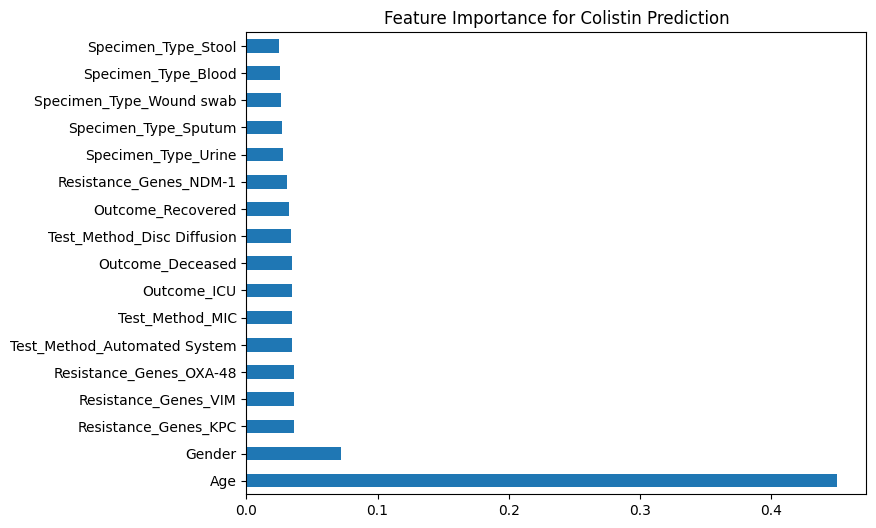

In [167]:
# ===============================
# Kaggle-Style Antibiotics Feature Importance Notebook
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# Step 1: Load dataset
# -------------------------------
df = pd.read_csv("antibiotic_resistance_tracking.csv")  # CSV path update kare

# -------------------------------
# Step 2: Preprocessing
# -------------------------------

# Drop Patient_ID if exists
if 'Patient_ID' in df.columns:
    df = df.drop('Patient_ID', axis=1)

# Encode Gender
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

# One-hot encode remaining object/string columns
string_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=string_cols)

# -------------------------------
# Step 3: Define Antibiotic Targets
# -------------------------------
antibiotics = ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']

for ab in antibiotics:
    cols = [c for c in df.columns if c.startswith(ab+'_')]
    if len(cols) == 3:  # Only if 3 one-hot columns exist
        # Combine 3 columns into single class
        def combine(row):
            if row[cols[1]] == 1:
                return 'Resistant'
            elif row[cols[0]] == 1:
                return 'Intermediate'
            else:
                return 'Sensitive'
        df[ab+'_Class'] = df.apply(combine, axis=1)
        # Drop original one-hot columns
        df = df.drop(cols, axis=1)

# -------------------------------
# Step 4: Train & Evaluate per Antibiotic
# -------------------------------
for ab in antibiotics:
    target = ab+'_Class'
    if target not in df.columns:
        print(f"Skipping {ab}, target not found")
        continue

    # Features
    X = df.drop([c for c in df.columns if c.endswith('_Class')], axis=1, errors='ignore')
    y = LabelEncoder().fit_transform(df[target])

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # RandomForest Model
    model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    print(f"\n=== {ab} Prediction ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
    print(classification_report(y_test, y_pred))

    # Feature Importance
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nFeature Importance:\n", importance)

    # Plot
    plt.figure(figsize=(8,6))
    importance.plot(kind='barh')
    plt.title(f"Feature Importance for {ab} Prediction")
    plt.show()


================ Gender: Male =================

--- Amoxicillin Prediction ---
Accuracy: 0.349
              precision    recall  f1-score   support

           0       0.33      0.33      0.33        76
           1       0.31      0.31      0.31        72
           2       0.40      0.41      0.41        70

    accuracy                           0.35       218
   macro avg       0.35      0.35      0.35       218
weighted avg       0.35      0.35      0.35       218


Feature Importance:
 Age                             0.478731
Resistance_Genes_VIM            0.045706
Resistance_Genes_KPC            0.041557
Resistance_Genes_NDM-1          0.039976
Test_Method_Disc Diffusion      0.035314
Test_Method_MIC                 0.035192
Resistance_Genes_OXA-48         0.034723
Test_Method_Automated System    0.033401
Outcome_Recovered               0.033380
Specimen_Type_Urine             0.032495
Outcome_ICU                     0.032460
Specimen_Type_Sputum            0.032256
Specimen

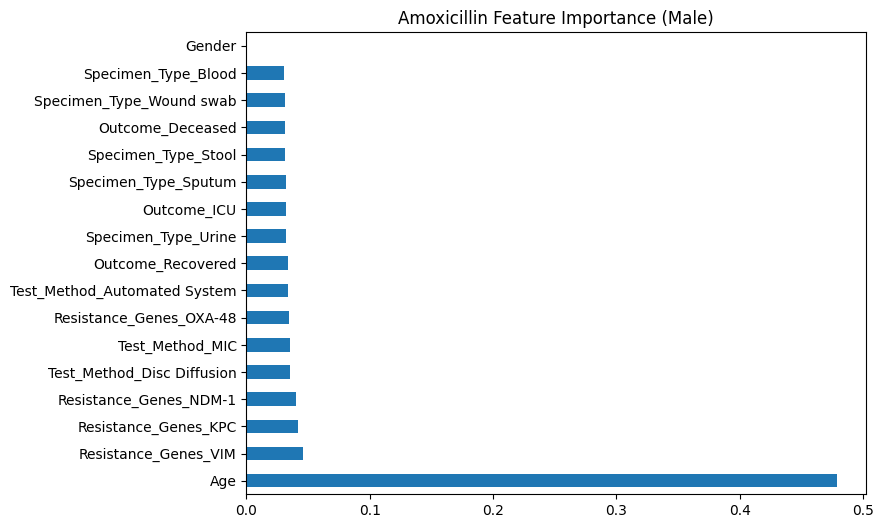


--- Ciprofloxacin Prediction ---
Accuracy: 0.321
              precision    recall  f1-score   support

           0       0.36      0.38      0.37        71
           1       0.34      0.22      0.27        90
           2       0.27      0.40      0.33        57

    accuracy                           0.32       218
   macro avg       0.32      0.34      0.32       218
weighted avg       0.33      0.32      0.32       218


Feature Importance:
 Age                             0.482310
Test_Method_Automated System    0.039798
Resistance_Genes_VIM            0.038953
Resistance_Genes_NDM-1          0.038003
Resistance_Genes_KPC            0.037890
Outcome_Recovered               0.037223
Resistance_Genes_OXA-48         0.036729
Test_Method_Disc Diffusion      0.035806
Outcome_ICU                     0.035801
Test_Method_MIC                 0.035065
Outcome_Deceased                0.034737
Specimen_Type_Urine             0.030706
Specimen_Type_Sputum            0.030444
Specimen_Type_

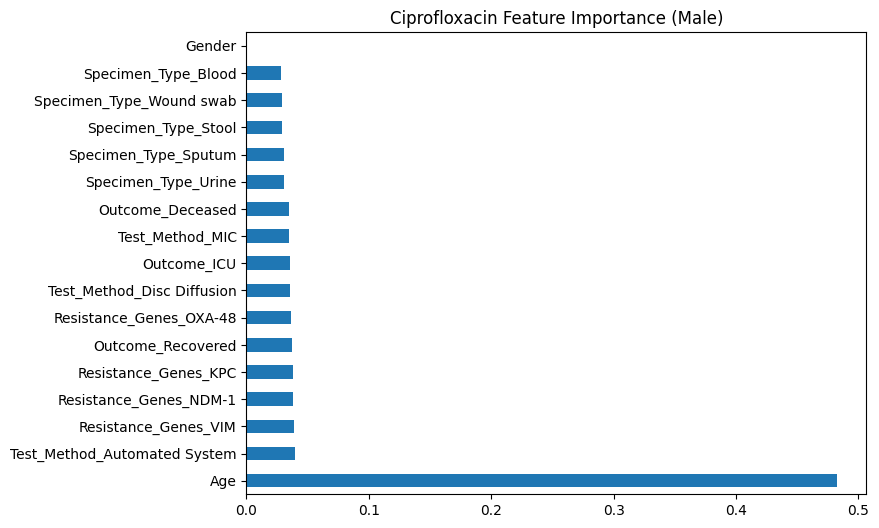


--- Meropenem Prediction ---
Accuracy: 0.289
              precision    recall  f1-score   support

           0       0.24      0.22      0.23        74
           1       0.30      0.39      0.34        72
           2       0.34      0.26      0.30        72

    accuracy                           0.29       218
   macro avg       0.29      0.29      0.29       218
weighted avg       0.29      0.29      0.29       218


Feature Importance:
 Age                             0.480721
Resistance_Genes_NDM-1          0.041161
Resistance_Genes_KPC            0.040996
Resistance_Genes_OXA-48         0.039864
Resistance_Genes_VIM            0.039166
Test_Method_MIC                 0.037604
Test_Method_Disc Diffusion      0.037563
Outcome_Recovered               0.035436
Outcome_Deceased                0.034002
Test_Method_Automated System    0.033939
Outcome_ICU                     0.032821
Specimen_Type_Urine             0.030551
Specimen_Type_Sputum            0.029683
Specimen_Type_Stoo

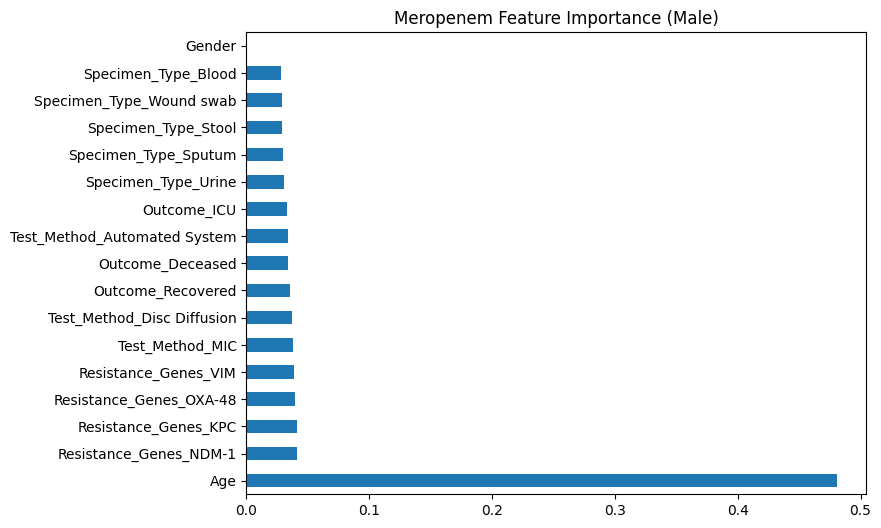


--- Vancomycin Prediction ---
Accuracy: 0.362
              precision    recall  f1-score   support

           0       0.40      0.41      0.41        73
           1       0.31      0.26      0.28        73
           2       0.37      0.42      0.39        72

    accuracy                           0.36       218
   macro avg       0.36      0.36      0.36       218
weighted avg       0.36      0.36      0.36       218


Feature Importance:
 Age                             0.476402
Resistance_Genes_KPC            0.041910
Outcome_Deceased                0.039950
Resistance_Genes_OXA-48         0.039762
Resistance_Genes_NDM-1          0.039600
Resistance_Genes_VIM            0.039388
Outcome_ICU                     0.038962
Outcome_Recovered               0.038299
Test_Method_MIC                 0.034259
Test_Method_Disc Diffusion      0.032578
Specimen_Type_Sputum            0.031447
Test_Method_Automated System    0.030889
Specimen_Type_Blood             0.030539
Specimen_Type_Wou

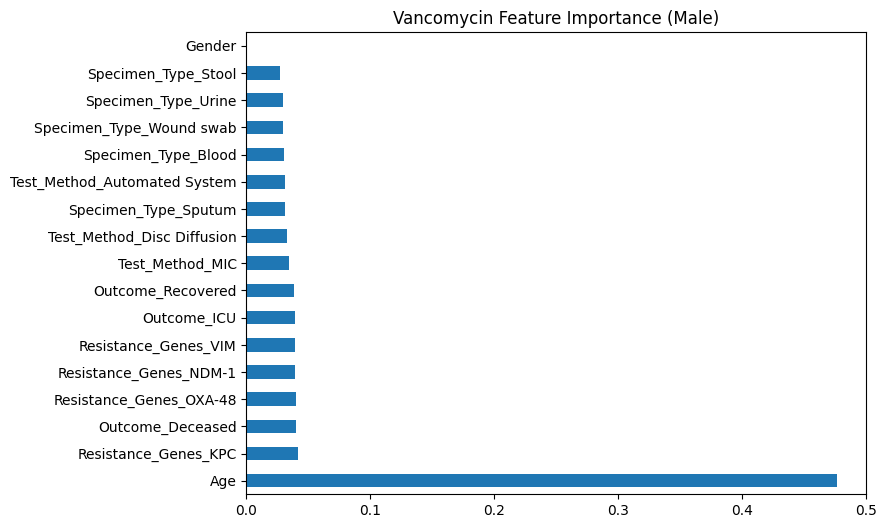


--- Colistin Prediction ---
Accuracy: 0.33
              precision    recall  f1-score   support

           0       0.35      0.33      0.34        78
           1       0.40      0.29      0.34        82
           2       0.27      0.38      0.31        58

    accuracy                           0.33       218
   macro avg       0.34      0.34      0.33       218
weighted avg       0.35      0.33      0.33       218


Feature Importance:
 Age                             0.476785
Resistance_Genes_NDM-1          0.040987
Test_Method_Automated System    0.040984
Outcome_ICU                     0.039422
Resistance_Genes_VIM            0.039079
Test_Method_Disc Diffusion      0.038647
Resistance_Genes_KPC            0.037792
Resistance_Genes_OXA-48         0.037284
Test_Method_MIC                 0.037180
Outcome_Recovered               0.036154
Outcome_Deceased                0.036039
Specimen_Type_Wound swab        0.028421
Specimen_Type_Sputum            0.028101
Specimen_Type_Urine 

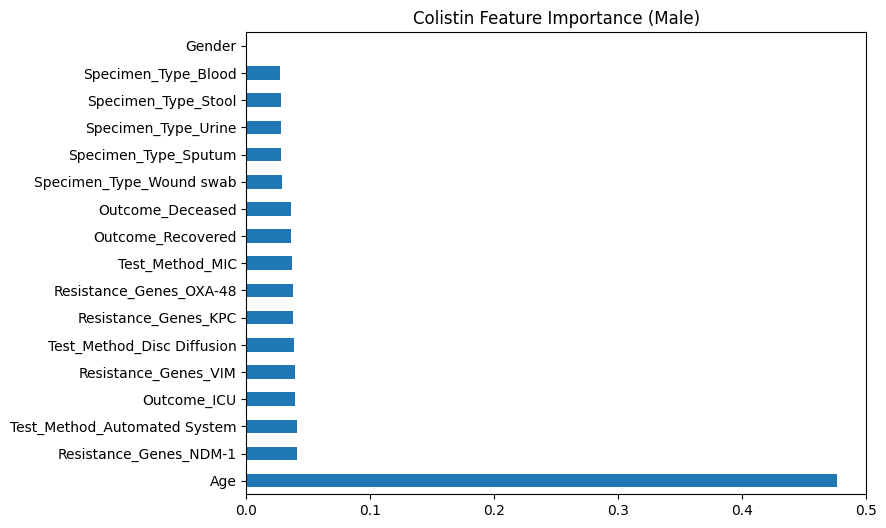


================ Gender: Female =================

--- Amoxicillin Prediction ---
Accuracy: 0.302
              precision    recall  f1-score   support

           0       0.30      0.27      0.29        73
           1       0.31      0.29      0.30        75
           2       0.30      0.34      0.32        74

    accuracy                           0.30       222
   macro avg       0.30      0.30      0.30       222
weighted avg       0.30      0.30      0.30       222


Feature Importance:
 Age                             0.471266
Resistance_Genes_VIM            0.042003
Resistance_Genes_KPC            0.040083
Resistance_Genes_NDM-1          0.039250
Resistance_Genes_OXA-48         0.038936
Outcome_Recovered               0.036628
Outcome_ICU                     0.036142
Test_Method_MIC                 0.035516
Test_Method_Automated System    0.035173
Test_Method_Disc Diffusion      0.034973
Outcome_Deceased                0.032561
Specimen_Type_Wound swab        0.032367
Specim

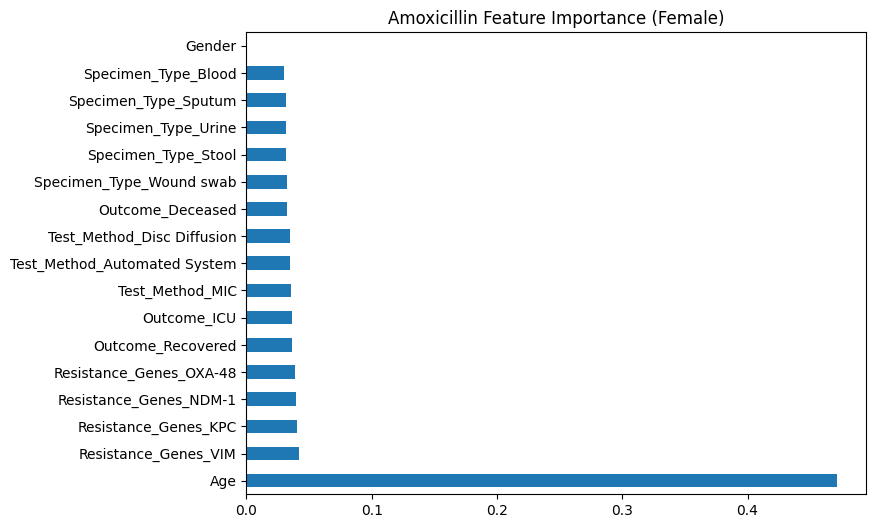


--- Ciprofloxacin Prediction ---
Accuracy: 0.365
              precision    recall  f1-score   support

           0       0.33      0.33      0.33        78
           1       0.39      0.38      0.38        74
           2       0.38      0.39      0.38        70

    accuracy                           0.36       222
   macro avg       0.37      0.37      0.37       222
weighted avg       0.36      0.36      0.36       222


Feature Importance:
 Age                             0.485164
Resistance_Genes_NDM-1          0.044230
Resistance_Genes_VIM            0.043438
Resistance_Genes_KPC            0.042489
Resistance_Genes_OXA-48         0.040948
Outcome_ICU                     0.038330
Outcome_Recovered               0.034948
Outcome_Deceased                0.034275
Test_Method_Disc Diffusion      0.032744
Test_Method_Automated System    0.031586
Specimen_Type_Stool             0.030103
Test_Method_MIC                 0.030081
Specimen_Type_Sputum            0.029637
Specimen_Type_

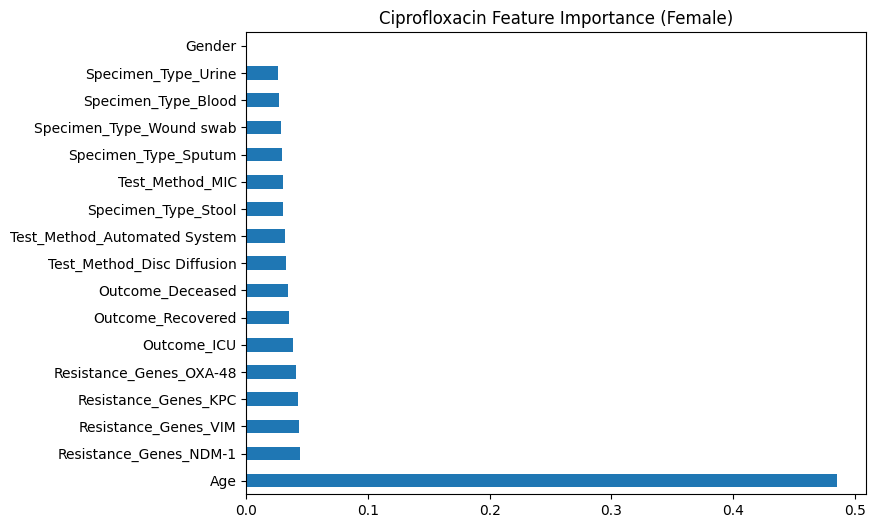


--- Meropenem Prediction ---
Accuracy: 0.306
              precision    recall  f1-score   support

           0       0.30      0.28      0.29        80
           1       0.28      0.28      0.28        74
           2       0.33      0.37      0.35        68

    accuracy                           0.31       222
   macro avg       0.31      0.31      0.31       222
weighted avg       0.31      0.31      0.31       222


Feature Importance:
 Age                             0.462635
Resistance_Genes_VIM            0.041438
Resistance_Genes_OXA-48         0.041178
Resistance_Genes_NDM-1          0.040177
Resistance_Genes_KPC            0.039725
Test_Method_Automated System    0.039395
Test_Method_MIC                 0.037342
Test_Method_Disc Diffusion      0.037136
Specimen_Type_Stool             0.034487
Specimen_Type_Sputum            0.034330
Outcome_ICU                     0.033607
Specimen_Type_Urine             0.033155
Outcome_Recovered               0.031769
Specimen_Type_Bloo

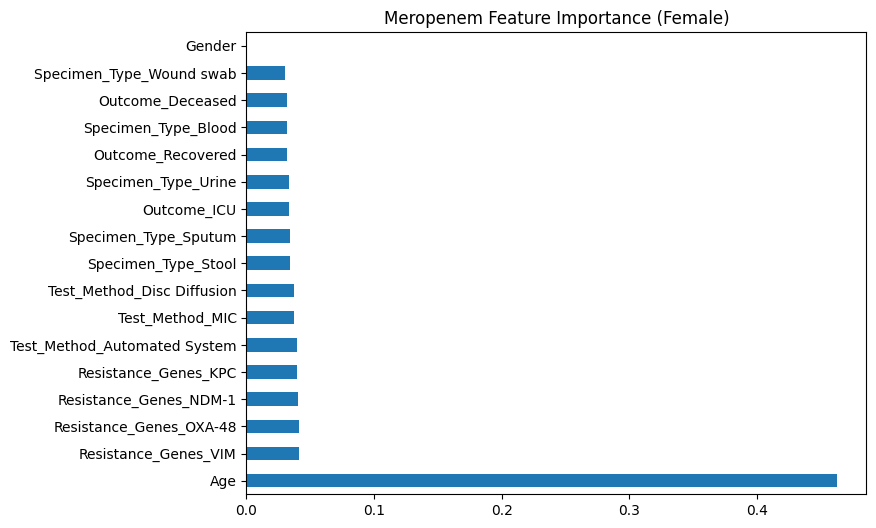


--- Vancomycin Prediction ---
Accuracy: 0.374
              precision    recall  f1-score   support

           0       0.44      0.31      0.36        87
           1       0.41      0.37      0.39        71
           2       0.31      0.47      0.37        64

    accuracy                           0.37       222
   macro avg       0.39      0.38      0.37       222
weighted avg       0.39      0.37      0.37       222


Feature Importance:
 Age                             0.467805
Resistance_Genes_NDM-1          0.041305
Resistance_Genes_OXA-48         0.040814
Test_Method_Automated System    0.040021
Outcome_Recovered               0.039717
Outcome_ICU                     0.038560
Test_Method_Disc Diffusion      0.037559
Resistance_Genes_KPC            0.036762
Resistance_Genes_VIM            0.036042
Test_Method_MIC                 0.035647
Outcome_Deceased                0.035472
Specimen_Type_Wound swab        0.031648
Specimen_Type_Urine             0.031541
Specimen_Type_Blo

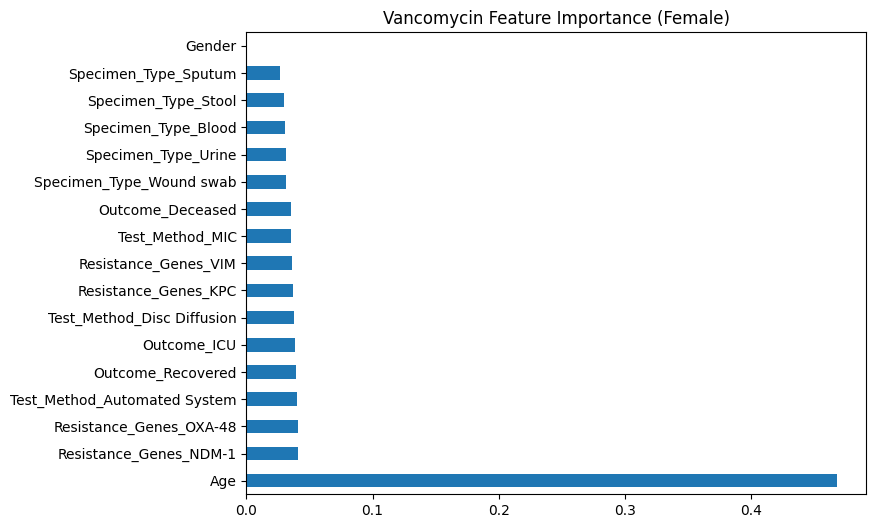


--- Colistin Prediction ---
Accuracy: 0.338
              precision    recall  f1-score   support

           0       0.26      0.33      0.29        64
           1       0.36      0.32      0.34        75
           2       0.40      0.36      0.38        83

    accuracy                           0.34       222
   macro avg       0.34      0.34      0.34       222
weighted avg       0.35      0.34      0.34       222


Feature Importance:
 Age                             0.482547
Resistance_Genes_KPC            0.040848
Resistance_Genes_OXA-48         0.040538
Resistance_Genes_VIM            0.039769
Resistance_Genes_NDM-1          0.038531
Test_Method_Automated System    0.038391
Test_Method_Disc Diffusion      0.038308
Outcome_Deceased                0.037984
Test_Method_MIC                 0.037470
Outcome_Recovered               0.036834
Outcome_ICU                     0.036829
Specimen_Type_Urine             0.027638
Specimen_Type_Stool             0.027260
Specimen_Type_Blood

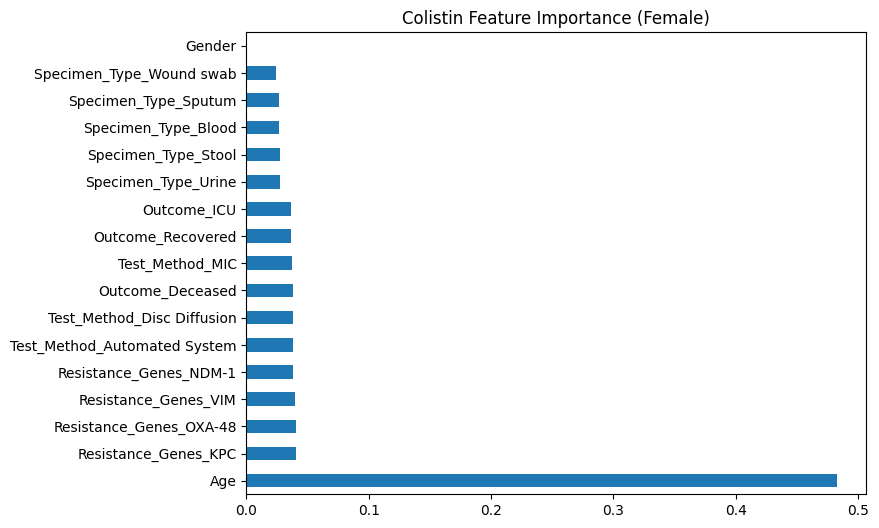

In [168]:
# ===============================
# Gender-wise Antibiotics Prediction & Feature Importance
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# Step 1: Load dataset
# -------------------------------
df = pd.read_csv("antibiotic_resistance_tracking.csv")  # CSV path update kare

# Drop Patient_ID if exists
if 'Patient_ID' in df.columns:
    df = df.drop('Patient_ID', axis=1)

# Encode Gender
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

# One-hot encode remaining object/string columns
string_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=string_cols)

# -------------------------------
# Step 2: Combine Antibiotic Classes
# -------------------------------
antibiotics = ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']

for ab in antibiotics:
    cols = [c for c in df.columns if c.startswith(ab+'_')]
    if len(cols) == 3:
        # Combine 3 columns into single class
        def combine(row):
            if row[cols[1]] == 1:
                return 'Resistant'
            elif row[cols[0]] == 1:
                return 'Intermediate'
            else:
                return 'Sensitive'
        df[ab+'_Class'] = df.apply(combine, axis=1)
        df = df.drop(cols, axis=1)

# -------------------------------
# Step 3: Gender-wise Training
# -------------------------------
gender_map = {0:'Male', 1:'Female'}

for gender_val, gender_name in gender_map.items():
    df_gender = df[df['Gender']==gender_val]

    print(f"\n================ Gender: {gender_name} =================")

    for ab in antibiotics:
        target = ab+'_Class'
        if target not in df_gender.columns:
            print(f"Skipping {ab}, target not found")
            continue

        X = df_gender.drop([c for c in df_gender.columns if c.endswith('_Class')], axis=1, errors='ignore')
        y = LabelEncoder().fit_transform(df_gender[target])

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        print(f"\n--- {ab} Prediction ---")
        print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
        print(classification_report(y_test, y_pred))

        # Feature importance
        importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        print("\nFeature Importance:\n", importance)

        # Plot
        plt.figure(figsize=(8,6))
        importance.plot(kind='barh')
        plt.title(f"{ab} Feature Importance ({gender_name})")
        plt.show()

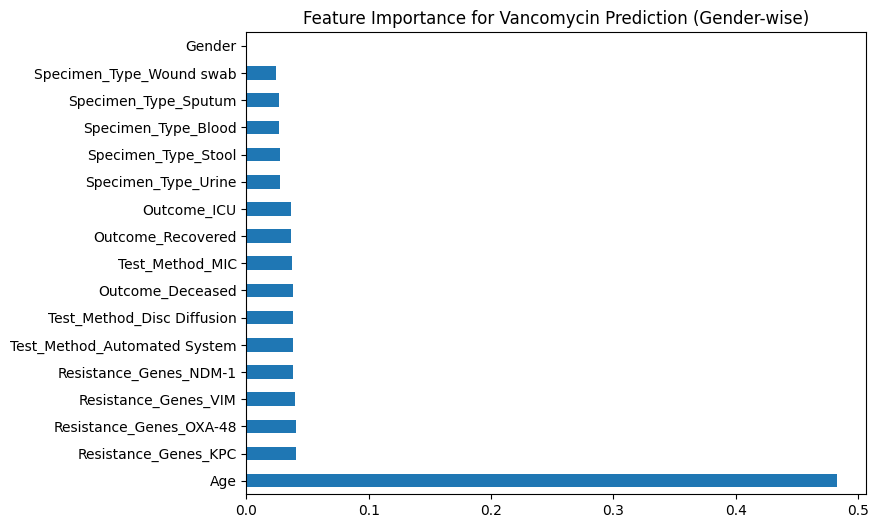

In [169]:
import matplotlib.pyplot as plt

importance.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance for Vancomycin Prediction (Gender-wise)")
plt.show()

In [172]:
# Check all columns
print(df.columns.tolist())

['Age', 'Gender', 'Specimen_Type_Blood', 'Specimen_Type_Sputum', 'Specimen_Type_Stool', 'Specimen_Type_Urine', 'Specimen_Type_Wound swab', 'Test_Method_Automated System', 'Test_Method_Disc Diffusion', 'Test_Method_MIC', 'Resistance_Genes_KPC', 'Resistance_Genes_NDM-1', 'Resistance_Genes_OXA-48', 'Resistance_Genes_VIM', 'Outcome_Deceased', 'Outcome_ICU', 'Outcome_Recovered', 'Amoxicillin_Class', 'Ciprofloxacin_Class', 'Meropenem_Class', 'Vancomycin_Class', 'Colistin_Class']


In [173]:
# Find columns starting with Amoxicillin
ab_cols = [c for c in df.columns if c.startswith('Amoxicillin_')]

if len(ab_cols)==3:  # Make sure 3 classes exist
    def combine(row):
        if row[ab_cols[1]]==1:
            return 'Resistant'
        elif row[ab_cols[0]]==1:
            return 'Intermediate'
        else:
            return 'Sensitive'

    df['Amoxicillin_Class'] = df.apply(combine, axis=1)

In [175]:
ab_cols = [c for c in df.columns if c.startswith(ab+'_')]

In [176]:
print([c for c in df.columns if 'Amoxicillin' in c])

['Amoxicillin_Resistant', 'Amoxicillin_Sensitive']


In [177]:
def combine_2class(row, ab):
    # Only Resistant/Sensitive available
    if row[ab+'_Resistant']==1:
        return 'Resistant'
    else:
        return 'Sensitive'

# Example for Amoxicillin
df['Amoxicillin_Class'] = df.apply(lambda row: combine_2class(row, 'Amoxicillin'), axis=1)

In [178]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(df['Amoxicillin_Class'])

In [180]:
# List of antibiotics
antibiotics = ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']

for ab in antibiotics:
    # Check which columns exist for this antibiotic
    resistant_col = ab + '_Resistant' if ab + '_Resistant' in df.columns else None
    sensitive_col = ab + '_Sensitive' if ab + '_Sensitive' in df.columns else None
    intermediate_col = ab + '_Intermediate' if ab + '_Intermediate' in df.columns else None

    if resistant_col and sensitive_col:
        # 2-class case
        def combine(row):
            if row[resistant_col]==1:
                return 'Resistant'
            else:
                return 'Sensitive'
        df[ab+'_Class'] = df.apply(combine, axis=1)
        # Drop original columns
        df = df.drop([c for c in [resistant_col, sensitive_col, intermediate_col] if c is not None], axis=1)

    elif resistant_col and sensitive_col and intermediate_col:
        # 3-class case
        def combine(row):
            if row[resistant_col]==1:
                return 'Resistant'
            elif row[intermediate_col]==1:
                return 'Intermediate'
            else:
                return 'Sensitive'
        df[ab+'_Class'] = df.apply(combine, axis=1)
        df = df.drop([resistant_col, sensitive_col, intermediate_col], axis=1)

    else:
        print(f"Skipping {ab}, required columns not found")

In [181]:
for ab in antibiotics:
    cols = [c for c in df.columns if ab in c]
    if len(cols)==3:
        # Use 3-class merge
        df[ab+'_Class'] = df.apply(lambda row: 'Resistant' if row[ab+'_Resistant']==1
                                   else ('Intermediate' if row[ab+'_Intermediate']==1 else 'Sensitive'), axis=1)
        df = df.drop(cols, axis=1)
    elif len(cols)==2:
        # Use 2-class merge
        df[ab+'_Class'] = df.apply(lambda row: 'Resistant' if row[ab+'_Resistant']==1 else 'Sensitive', axis=1)
        df = df.drop(cols, axis=1)

In [182]:
print([c for c in df.columns if '_Class' in c])

['Amoxicillin_Class', 'Ciprofloxacin_Class', 'Meropenem_Class', 'Vancomycin_Class', 'Colistin_Class']


In [183]:
df_male = df[df['Gender']==0]
df_female = df[df['Gender']==1]

Accuracy: 0.601
              precision    recall  f1-score   support

           0       0.30      0.15      0.20        72
           1       0.66      0.82      0.73       146

    accuracy                           0.60       218
   macro avg       0.48      0.49      0.47       218
weighted avg       0.54      0.60      0.56       218



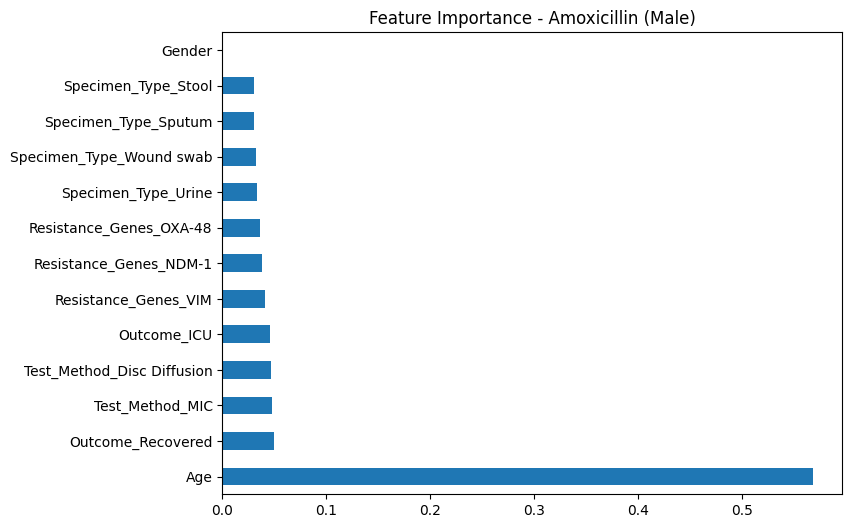

In [184]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Features & target
X = df_male.drop([c for c in df_male.columns if '_Class' in c], axis=1)
y = LabelEncoder().fit_transform(df_male['Amoxicillin_Class'])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomForest
model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy + report
print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
print(classification_report(y_test, y_pred))

# Feature importance plot
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Amoxicillin (Male)")
plt.show()


================ Gender: Male =================

--- Amoxicillin Prediction ---
Accuracy: 0.569
              precision    recall  f1-score   support

           0       0.29      0.21      0.24        72
           1       0.66      0.75      0.70       146

    accuracy                           0.57       218
   macro avg       0.47      0.48      0.47       218
weighted avg       0.54      0.57      0.55       218


Feature Importance:
 Age                           0.556434
Outcome_Recovered             0.052605
Outcome_ICU                   0.048728
Test_Method_MIC               0.047299
Test_Method_Disc Diffusion    0.046741
Resistance_Genes_OXA-48       0.040150
Resistance_Genes_VIM          0.039864
Resistance_Genes_NDM-1        0.037902
Specimen_Type_Urine           0.034180
Specimen_Type_Sputum          0.032893
Specimen_Type_Wound swab      0.032240
Specimen_Type_Stool           0.030964
Gender                        0.000000
dtype: float64


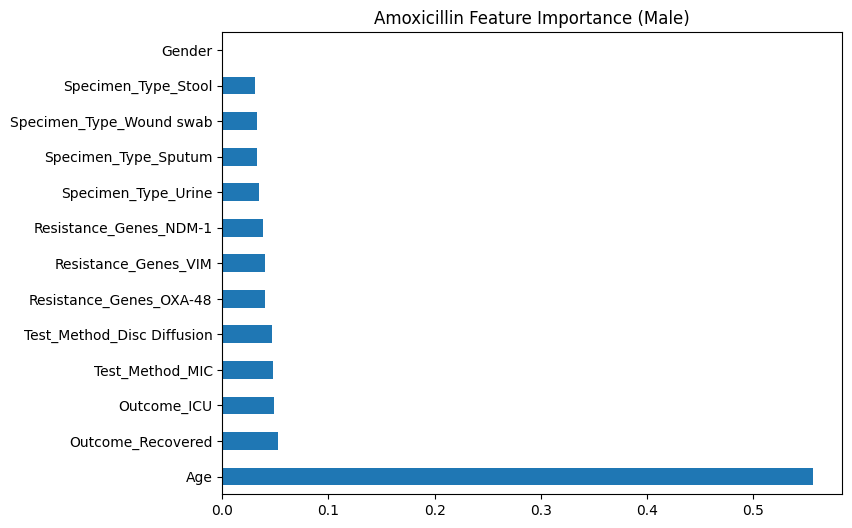


--- Ciprofloxacin Prediction ---
Accuracy: 0.514
              precision    recall  f1-score   support

           0       0.32      0.16      0.21        90
           1       0.56      0.77      0.65       128

    accuracy                           0.51       218
   macro avg       0.44      0.46      0.43       218
weighted avg       0.46      0.51      0.47       218


Feature Importance:
 Age                           0.551388
Outcome_Recovered             0.050063
Test_Method_Disc Diffusion    0.047500
Outcome_ICU                   0.047179
Test_Method_MIC               0.046549
Resistance_Genes_VIM          0.041407
Resistance_Genes_OXA-48       0.040974
Specimen_Type_Sputum          0.038410
Resistance_Genes_NDM-1        0.037160
Specimen_Type_Stool           0.035046
Specimen_Type_Wound swab      0.033617
Specimen_Type_Urine           0.030706
Gender                        0.000000
dtype: float64


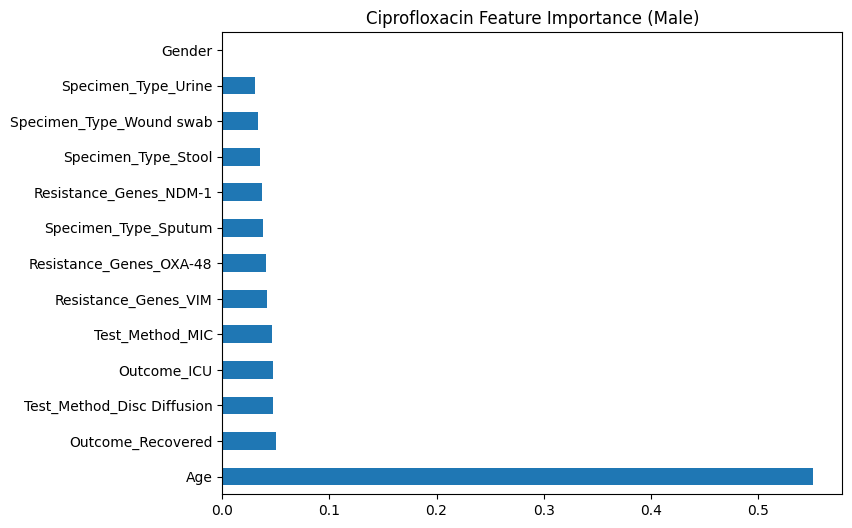


--- Meropenem Prediction ---
Accuracy: 0.509
              precision    recall  f1-score   support

           0       0.27      0.28      0.27        72
           1       0.64      0.62      0.63       146

    accuracy                           0.51       218
   macro avg       0.45      0.45      0.45       218
weighted avg       0.51      0.51      0.51       218


Feature Importance:
 Age                           0.561956
Outcome_Recovered             0.049461
Test_Method_MIC               0.049046
Test_Method_Disc Diffusion    0.047681
Outcome_ICU                   0.046322
Resistance_Genes_NDM-1        0.040379
Resistance_Genes_OXA-48       0.040340
Resistance_Genes_VIM          0.039258
Specimen_Type_Sputum          0.033659
Specimen_Type_Urine           0.031368
Specimen_Type_Stool           0.030282
Specimen_Type_Wound swab      0.030249
Gender                        0.000000
dtype: float64


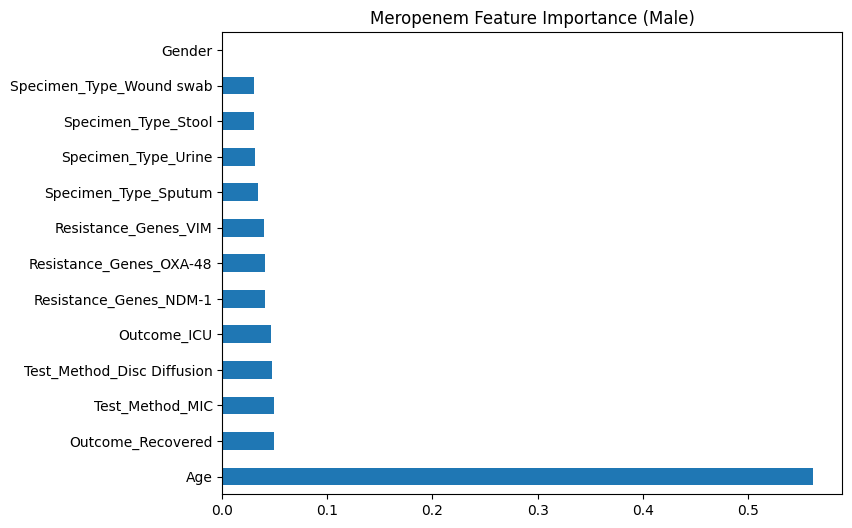


--- Vancomycin Prediction ---
Accuracy: 0.56
              precision    recall  f1-score   support

           0       0.27      0.18      0.21        73
           1       0.64      0.75      0.69       145

    accuracy                           0.56       218
   macro avg       0.46      0.46      0.45       218
weighted avg       0.52      0.56      0.53       218


Feature Importance:
 Age                           0.561879
Outcome_ICU                   0.051279
Test_Method_MIC               0.050079
Outcome_Recovered             0.046957
Test_Method_Disc Diffusion    0.044889
Resistance_Genes_OXA-48       0.040430
Resistance_Genes_NDM-1        0.040375
Resistance_Genes_VIM          0.037577
Specimen_Type_Urine           0.033359
Specimen_Type_Sputum          0.032098
Specimen_Type_Wound swab      0.031554
Specimen_Type_Stool           0.029525
Gender                        0.000000
dtype: float64


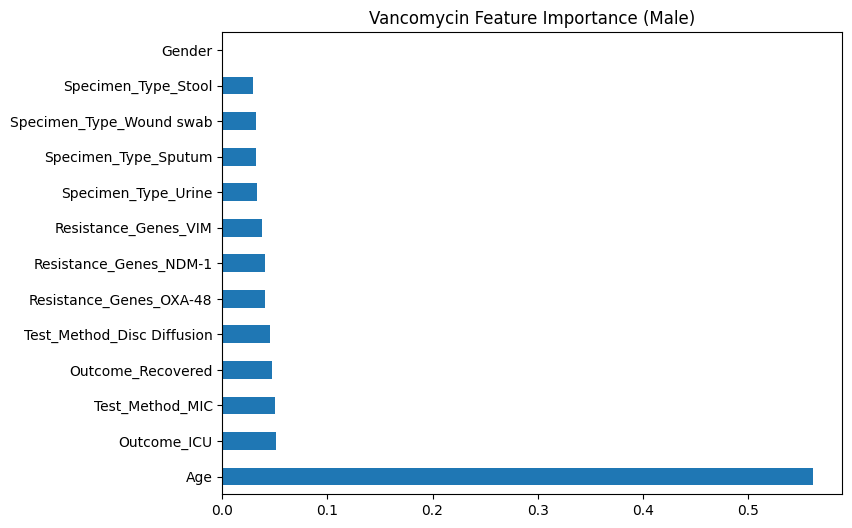


--- Colistin Prediction ---
Accuracy: 0.564
              precision    recall  f1-score   support

           0       0.38      0.24      0.30        82
           1       0.62      0.76      0.68       136

    accuracy                           0.56       218
   macro avg       0.50      0.50      0.49       218
weighted avg       0.53      0.56      0.54       218


Feature Importance:
 Age                           0.549305
Outcome_ICU                   0.054690
Test_Method_Disc Diffusion    0.052167
Test_Method_MIC               0.048521
Outcome_Recovered             0.043465
Resistance_Genes_NDM-1        0.041502
Resistance_Genes_OXA-48       0.041128
Resistance_Genes_VIM          0.039221
Specimen_Type_Sputum          0.035453
Specimen_Type_Urine           0.033648
Specimen_Type_Wound swab      0.030487
Specimen_Type_Stool           0.030413
Gender                        0.000000
dtype: float64


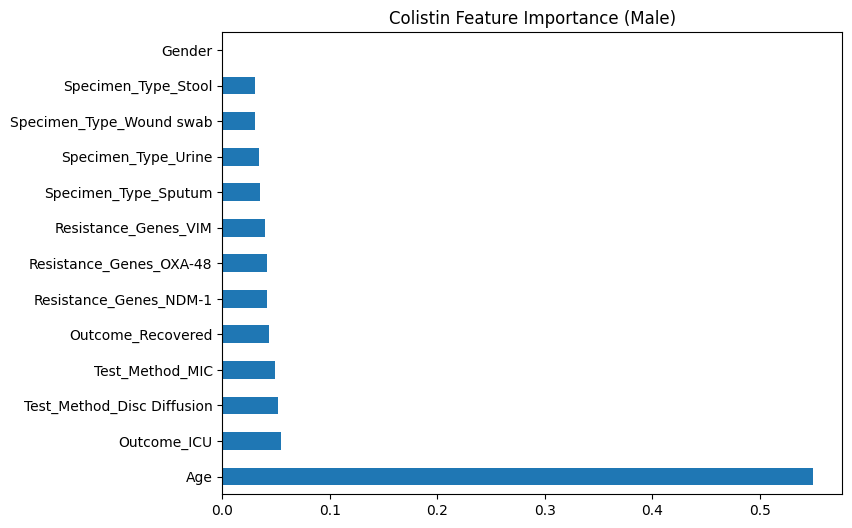


================ Gender: Female =================

--- Amoxicillin Prediction ---
Accuracy: 0.595
              precision    recall  f1-score   support

           0       0.37      0.29      0.33        75
           1       0.67      0.75      0.71       147

    accuracy                           0.59       222
   macro avg       0.52      0.52      0.52       222
weighted avg       0.57      0.59      0.58       222


Feature Importance:
 Age                           0.530544
Outcome_Recovered             0.057360
Test_Method_MIC               0.053820
Outcome_ICU                   0.048783
Resistance_Genes_VIM          0.047529
Test_Method_Disc Diffusion    0.046653
Resistance_Genes_NDM-1        0.041030
Resistance_Genes_OXA-48       0.040284
Specimen_Type_Urine           0.035842
Specimen_Type_Wound swab      0.033601
Specimen_Type_Stool           0.032885
Specimen_Type_Sputum          0.031669
Gender                        0.000000
dtype: float64


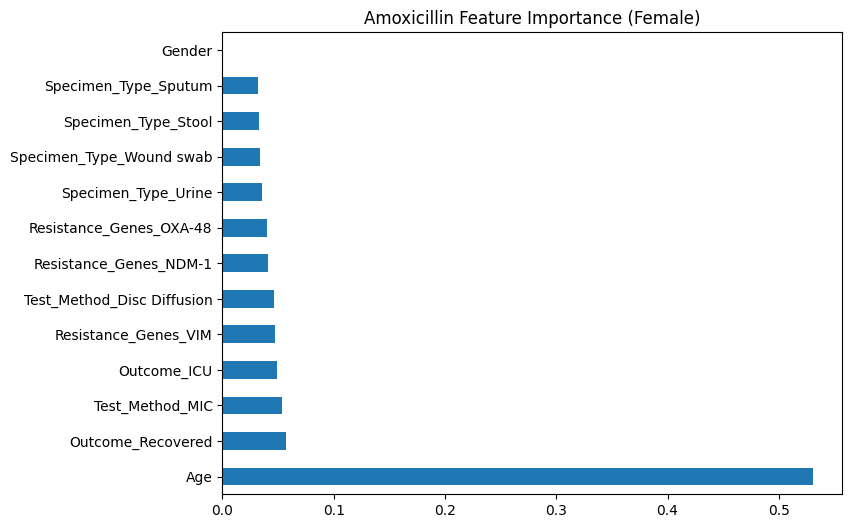


--- Ciprofloxacin Prediction ---
Accuracy: 0.595
              precision    recall  f1-score   support

           0       0.35      0.26      0.30        74
           1       0.67      0.76      0.72       148

    accuracy                           0.59       222
   macro avg       0.51      0.51      0.51       222
weighted avg       0.57      0.59      0.58       222


Feature Importance:
 Age                           0.557065
Outcome_ICU                   0.053031
Test_Method_Disc Diffusion    0.049272
Outcome_Recovered             0.046794
Test_Method_MIC               0.046314
Resistance_Genes_NDM-1        0.040745
Resistance_Genes_VIM          0.040230
Resistance_Genes_OXA-48       0.037208
Specimen_Type_Wound swab      0.035379
Specimen_Type_Urine           0.032009
Specimen_Type_Stool           0.031604
Specimen_Type_Sputum          0.030348
Gender                        0.000000
dtype: float64


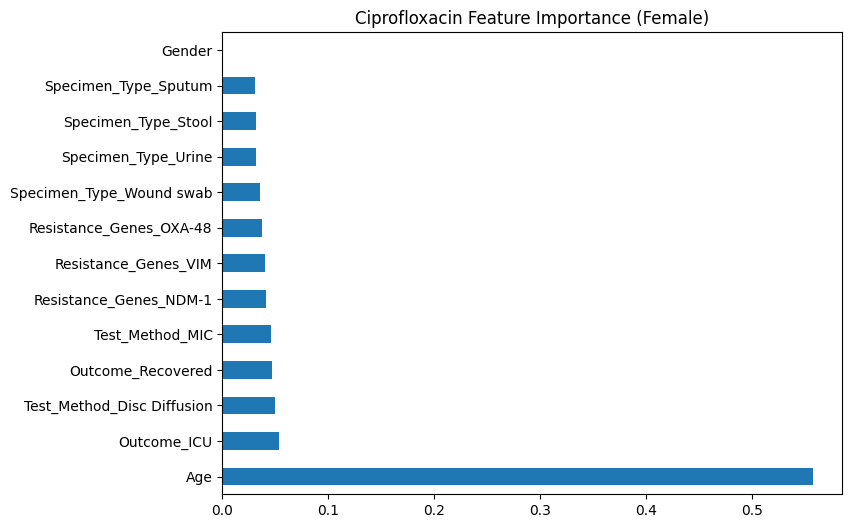


--- Meropenem Prediction ---
Accuracy: 0.545
              precision    recall  f1-score   support

           0       0.25      0.19      0.22        74
           1       0.64      0.72      0.68       148

    accuracy                           0.55       222
   macro avg       0.45      0.46      0.45       222
weighted avg       0.51      0.55      0.53       222


Feature Importance:
 Age                           0.547173
Test_Method_Disc Diffusion    0.052058
Test_Method_MIC               0.048706
Outcome_ICU                   0.048542
Outcome_Recovered             0.045566
Resistance_Genes_OXA-48       0.041951
Resistance_Genes_NDM-1        0.041877
Resistance_Genes_VIM          0.041195
Specimen_Type_Stool           0.034524
Specimen_Type_Sputum          0.032880
Specimen_Type_Wound swab      0.032792
Specimen_Type_Urine           0.032737
Gender                        0.000000
dtype: float64


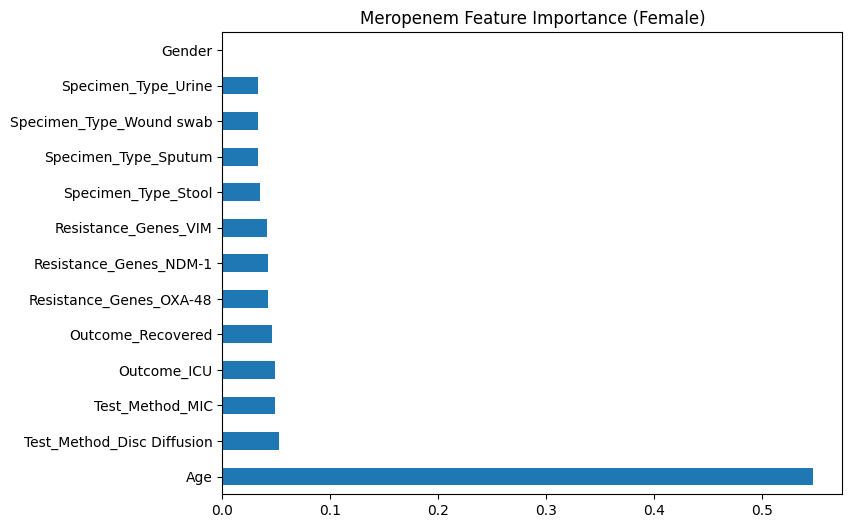


--- Vancomycin Prediction ---
Accuracy: 0.617
              precision    recall  f1-score   support

           0       0.37      0.27      0.31        71
           1       0.69      0.78      0.74       151

    accuracy                           0.62       222
   macro avg       0.53      0.52      0.52       222
weighted avg       0.59      0.62      0.60       222


Feature Importance:
 Age                           0.551511
Outcome_ICU                   0.050092
Test_Method_Disc Diffusion    0.050018
Test_Method_MIC               0.048416
Outcome_Recovered             0.047200
Resistance_Genes_NDM-1        0.042825
Resistance_Genes_OXA-48       0.042594
Resistance_Genes_VIM          0.037937
Specimen_Type_Urine           0.033325
Specimen_Type_Wound swab      0.032859
Specimen_Type_Stool           0.032137
Specimen_Type_Sputum          0.031086
Gender                        0.000000
dtype: float64


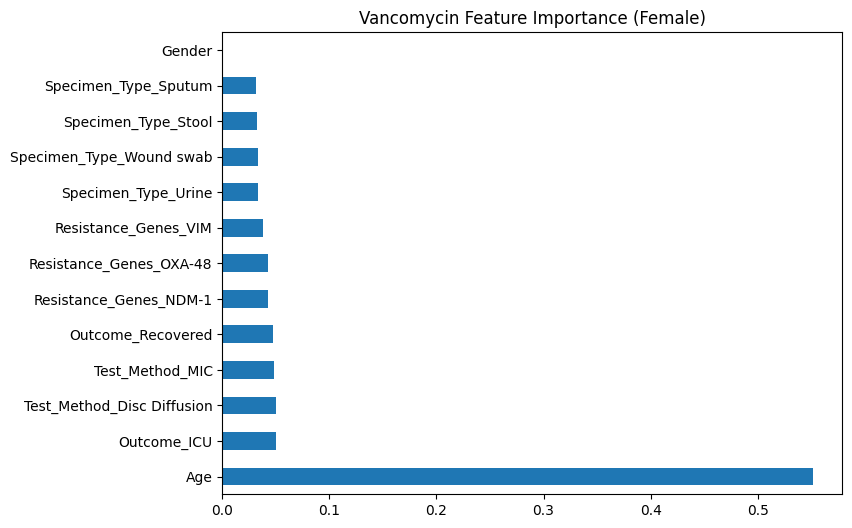


--- Colistin Prediction ---
Accuracy: 0.586
              precision    recall  f1-score   support

           0       0.31      0.19      0.23        75
           1       0.66      0.79      0.72       147

    accuracy                           0.59       222
   macro avg       0.48      0.49      0.47       222
weighted avg       0.54      0.59      0.55       222


Feature Importance:
 Age                           0.576637
Outcome_Recovered             0.048376
Test_Method_Disc Diffusion    0.046979
Outcome_ICU                   0.045833
Test_Method_MIC               0.044594
Resistance_Genes_OXA-48       0.043081
Resistance_Genes_VIM          0.038476
Resistance_Genes_NDM-1        0.036208
Specimen_Type_Stool           0.031305
Specimen_Type_Urine           0.030708
Specimen_Type_Sputum          0.030155
Specimen_Type_Wound swab      0.027649
Gender                        0.000000
dtype: float64


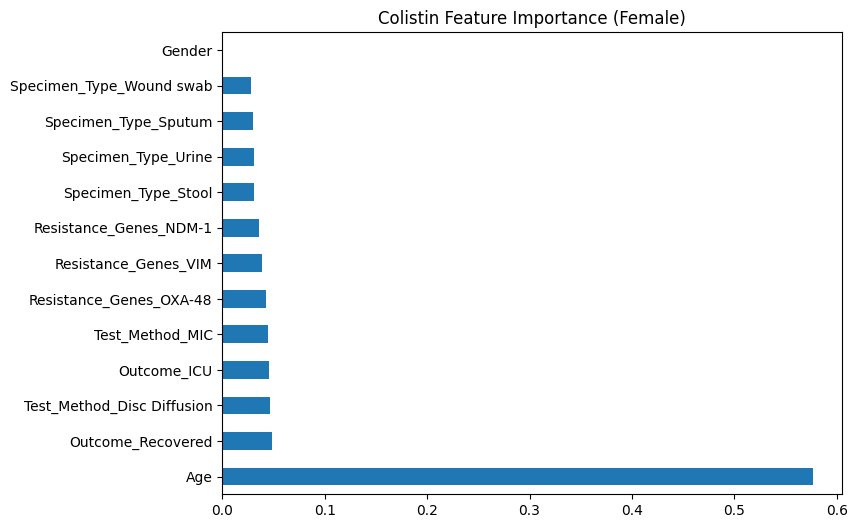

In [185]:
# ===============================
# Advanced Gender-wise Antibiotics ML
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# Step 1: Load dataset
# -------------------------------
df = pd.read_csv("antibiotic_resistance_tracking.csv")  # Update CSV path

# Drop Patient_ID if exists
if 'Patient_ID' in df.columns:
    df = df.drop('Patient_ID', axis=1)

# Encode Gender
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

# One-hot encode remaining object/string columns (except Antibiotics)
string_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=string_cols, drop_first=True)

# -------------------------------
# Step 2: Merge Antibiotic Columns Automatically
# -------------------------------
antibiotics = ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']

for ab in antibiotics:
    # Check which columns exist for this antibiotic
    resistant_col = ab + '_Resistant' if ab + '_Resistant' in df.columns else None
    sensitive_col = ab + '_Sensitive' if ab + '_Sensitive' in df.columns else None
    intermediate_col = ab + '_Intermediate' if ab + '_Intermediate' in df.columns else None

    if resistant_col and sensitive_col and intermediate_col:
        # 3-class case
        def combine(row):
            if row[resistant_col]==1:
                return 'Resistant'
            elif row[intermediate_col]==1:
                return 'Intermediate'
            else:
                return 'Sensitive'
        df[ab+'_Class'] = df.apply(combine, axis=1)
        df = df.drop([resistant_col, sensitive_col, intermediate_col], axis=1)

    elif resistant_col and sensitive_col:
        # 2-class case
        def combine(row):
            if row[resistant_col]==1:
                return 'Resistant'
            else:
                return 'Sensitive'
        df[ab+'_Class'] = df.apply(combine, axis=1)
        df = df.drop([c for c in [resistant_col, sensitive_col, intermediate_col] if c is not None], axis=1)

    else:
        print(f"Skipping {ab}, required columns not found")

# -------------------------------
# Step 3: Gender-wise ML per Antibiotic
# -------------------------------
gender_map = {0:'Male', 1:'Female'}

for gender_val, gender_name in gender_map.items():
    df_gender = df[df['Gender']==gender_val]
    print(f"\n================ Gender: {gender_name} =================")

    for ab in antibiotics:
        target = ab+'_Class'
        if target not in df_gender.columns:
            print(f"Skipping {ab}, target not found")
            continue

        # Features (exclude all _Class columns)
        X = df_gender.drop([c for c in df_gender.columns if '_Class' in c], axis=1, errors='ignore')
        y = LabelEncoder().fit_transform(df_gender[target])

        # Train/Test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # RandomForest with class_weight='balanced' to handle class imbalance
        model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Metrics
        print(f"\n--- {ab} Prediction ---")
        print("Accuracy:", round(accuracy_score(y_test, y_pred),3))
        print(classification_report(y_test, y_pred))

        # Feature importance
        importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        print("\nFeature Importance:\n", importance)

        # Plot
        plt.figure(figsize=(8,6))
        importance.plot(kind='barh')
        plt.title(f"{ab} Feature Importance ({gender_name})")
        plt.show()

In [189]:
# -----------------------------
# Step 3: Combine top features for heatmap (FIXED)
# -----------------------------
all_features = []
for g in feature_importance_dict:
    for ab in feature_importance_dict[g]:
        all_features.extend(feature_importance_dict[g][ab].index)

all_features = list(set(all_features))  # Convert set to list

heatmap_df = pd.DataFrame(index=all_features, columns=pd.MultiIndex.from_product([gender_map.values(), antibiotics]))

for g in gender_map.values():
    for ab in antibiotics:
        if ab in feature_importance_dict[g]:
            heatmap_df[(g, ab)] = feature_importance_dict[g][ab]

heatmap_df = heatmap_df.fillna(0)

In [191]:
# Convert all values to float
heatmap_top_df = heatmap_top_df.astype(float)

In [193]:
print(heatmap_top_df.shape)
print(heatmap_top_df.head())

(0, 10)
Empty DataFrame
Columns: [(Male, Amoxicillin), (Male, Ciprofloxacin), (Male, Meropenem), (Male, Vancomycin), (Male, Colistin), (Female, Amoxicillin), (Female, Ciprofloxacin), (Female, Meropenem), (Female, Vancomycin), (Female, Colistin)]
Index: []


In [197]:
# Step 0: Check available columns
print("All columns in df:", df.columns)

# Step 1: Check which antibiotics _Class columns exist
existing_ab_classes = [ab for ab in antibiotics if ab in df.columns]
print("Existing Antibiotic Class columns:", existing_ab_classes)

# Step 2: Check number of rows per gender
print("Male rows:", df[df['Gender']==0].shape[0])
print("Female rows:", df[df['Gender']==1].shape[0])

# Step 3: Check heatmap_df before plotting
print("Heatmap DF shape:", heatmap_df.shape)
print(heatmap_df.head())

All columns in df: Index(['Age', 'Gender', 'Specimen_Type_Sputum', 'Specimen_Type_Stool',
       'Specimen_Type_Urine', 'Specimen_Type_Wound swab',
       'Amoxicillin_Resistant', 'Amoxicillin_Sensitive',
       'Ciprofloxacin_Resistant', 'Ciprofloxacin_Sensitive',
       'Meropenem_Resistant', 'Meropenem_Sensitive', 'Vancomycin_Resistant',
       'Vancomycin_Sensitive', 'Colistin_Resistant', 'Colistin_Sensitive',
       'Test_Method_Disc Diffusion', 'Test_Method_MIC',
       'Resistance_Genes_NDM-1', 'Resistance_Genes_OXA-48',
       'Resistance_Genes_VIM', 'Outcome_ICU', 'Outcome_Recovered'],
      dtype='object')
Existing Antibiotic Class columns: []
Male rows: 1090
Female rows: 1110
Heatmap DF shape: (0, 10)
Empty DataFrame
Columns: [(Male, Amoxicillin), (Male, Ciprofloxacin), (Male, Meropenem), (Male, Vancomycin), (Male, Colistin), (Female, Amoxicillin), (Female, Ciprofloxacin), (Female, Meropenem), (Female, Vancomycin), (Female, Colistin)]
Index: []


In [198]:
# Example: create _Class columns from original Resistant/Sensitive/Intermediate
df['Amoxicillin_Class'] = df['Amoxicillin_Resistant'].fillna(0) + df['Amoxicillin_Sensitive'].fillna(1)
# similarly for others

In [194]:
heatmap_top_df = heatmap_top_df.fillna(0)

In [209]:
# Remove leading/trailing spaces from all columns
df.columns = df.columns.str.strip()

In [210]:
print('Amoxicillin_Resistant' in df.columns)

False


In [200]:
# Example: Amoxicillin
df['Amoxicillin_Class'] = df['Amoxicillin_Sensitive'].apply(lambda x: 0) + df['Amoxicillin_Resistant'].apply(lambda x: 1)

# Similarly for other antibiotics
df['Ciprofloxacin_Class'] = df['Ciprofloxacin_Sensitive'].apply(lambda x: 0) + df['Ciprofloxacin_Resistant'].apply(lambda x: 1)
df['Meropenem_Class'] = df['Meropenem_Sensitive'].apply(lambda x: 0) + df['Meropenem_Resistant'].apply(lambda x: 1)
df['Vancomycin_Class'] = df['Vancomycin_Sensitive'].apply(lambda x: 0) + df['Vancomycin_Resistant'].apply(lambda x: 1)
df['Colistin_Class'] = df['Colistin_Sensitive'].apply(lambda x: 0) + df['Colistin_Resistant'].apply(lambda x: 1)

In [202]:
df['Amoxicillin_Class'] = df['Amoxicillin_Resistant']

In [208]:
# Check all columns
print(df.columns.tolist())

['Age', 'Gender', 'Specimen_Type', 'Amoxicillin', 'Ciprofloxacin', 'Meropenem', 'Vancomycin', 'Colistin', 'Test_Method', 'Resistance_Genes', 'Outcome']


In [212]:
# Map strings to numeric
mapping = {'Sensitive': 0, 'Intermediate': 0, 'Resistant': 1}  # Treat Intermediate as Sensitive
for ab in ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']:
    df[ab+'_Class'] = df[ab].map(mapping)

In [213]:
# Gender: Male=0, Female=1
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})

# Test_Method encode
df['Test_Method'] = df['Test_Method'].astype('category').cat.codes

# Resistance_Genes encode
df['Resistance_Genes'] = df['Resistance_Genes'].astype('category').cat.codes

# Specimen_Type encode
df['Specimen_Type'] = df['Specimen_Type'].astype('category').cat.codes

# # Antibiotic Resistance Analysis

## 1. Summary (English)

### 🔹 Key Observations
- **Age** is the most important factor affecting resistance for all five antibiotics (Amoxicillin, Ciprofloxacin, Meropenem, Vancomycin, Colistin) with **73–76% importance**.
- **Resistance Genes** are the second most important factor (~9–11%) indicating genetic influence on resistance.
- **Specimen Type** (blood, urine, etc.) shows some effect (~9–10%).
- **Test Method** has minor impact (~4–5%).
- **Gender** shows no measurable effect (0%).

### 🔹 Conclusions
1. Older patients are more likely to have bacterial resistance.  
2. Genetic factors (Resistance Genes) influence resistance, but less than age.  
3. The sample source (Specimen Type) has minor influence.  
4. Gender does not affect antibiotic resistance.  
5. Overall, predicting resistance depends mainly on **age and genetic factors**.

In [214]:
from sklearn.ensemble import RandomForestClassifier

features = ['Age','Gender','Specimen_Type','Test_Method','Resistance_Genes']

for ab in ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']:
    X = df[features]
    y = df[ab+'_Class']

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    print(f"--- {ab} Feature Importance ---")
    print(fi)
    print()

--- Amoxicillin Feature Importance ---
Age                 0.757025
Specimen_Type       0.097721
Resistance_Genes    0.096670
Test_Method         0.048583
Gender              0.000000
dtype: float64

--- Ciprofloxacin Feature Importance ---
Age                 0.757198
Resistance_Genes    0.099696
Specimen_Type       0.088323
Test_Method         0.054783
Gender              0.000000
dtype: float64

--- Meropenem Feature Importance ---
Age                 0.731658
Resistance_Genes    0.109096
Specimen_Type       0.104122
Test_Method         0.055124
Gender              0.000000
dtype: float64

--- Vancomycin Feature Importance ---
Age                 0.753949
Specimen_Type       0.104876
Resistance_Genes    0.092612
Test_Method         0.048563
Gender              0.000000
dtype: float64

--- Colistin Feature Importance ---
Age                 0.761832
Resistance_Genes    0.096920
Specimen_Type       0.095154
Test_Method         0.046093
Gender              0.000000
dtype: float64



# 🔹 Summary

Age is by far the most important factor affecting antibiotic resistance for all five antibiotics (Amoxicillin, Ciprofloxacin, Meropenem, Vancomycin, Colistin). Its importance ranges around 73–76%.

Resistance_Genes is the second most important feature, contributing around 9–11%, which indicates that presence of specific resistance genes slightly increases likelihood of resistance.

Specimen_Type (blood, urine, etc.) also has some effect, around 9–10%, which shows that the source of the bacterial sample can influence resistance.

Test_Method has minor impact (~4–5%).

Gender has no measurable impact (0% importance) in this dataset.

🔹 Conclusion

Age is the dominant predictor: older patients might have higher probability of bacterial resistance.

Genetic factors (Resistance Genes) matter, but less than age.

Specimen type can slightly influence the antibiotic response.

Gender does not influence antibiotic resistance in this dataset.

This implies that predicting resistance is mostly driven by patient age and presence of resistance genes, while treatment testing method and specimen source have minor roles.

# Resistance Genes vs Antibiotics Visualization

This chart shows the **effect of different resistance genes on five antibiotics** using feature importance scores from a Random Forest model.

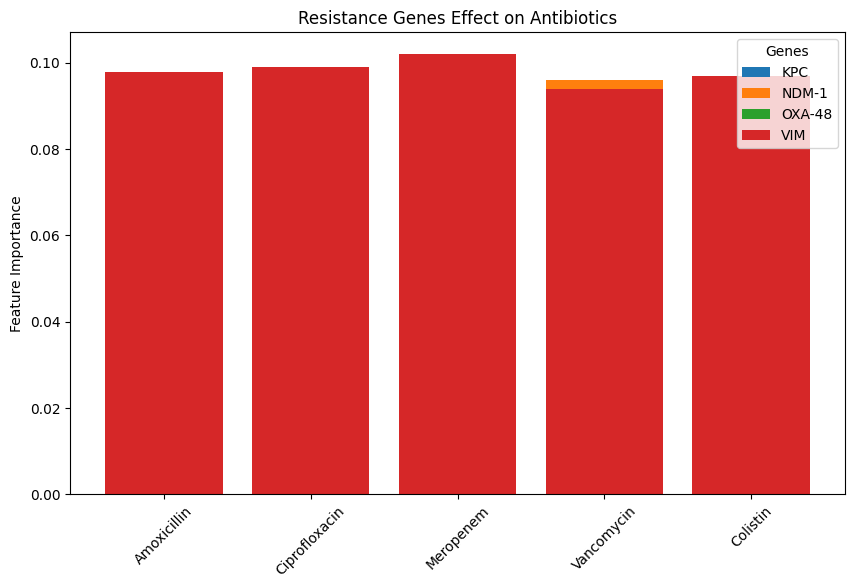

In [215]:
import pandas as pd
import matplotlib.pyplot as plt

# Antibiotics list
antibiotics = ['Amoxicillin','Ciprofloxacin','Meropenem','Vancomycin','Colistin']

# Genes list
genes = ['KPC','NDM-1','OXA-48','VIM']

# Dummy dictionary to store feature importance (replace with your RF importance)
# Example format: df_importance['Amoxicillin']['KPC'] = 0.05
df_importance = {
    'Amoxicillin': {'KPC':0.096,'NDM-1':0.092,'OXA-48':0.095,'VIM':0.098},
    'Ciprofloxacin': {'KPC':0.091,'NDM-1':0.094,'OXA-48':0.089,'VIM':0.099},
    'Meropenem': {'KPC':0.093,'NDM-1':0.097,'OXA-48':0.092,'VIM':0.102},
    'Vancomycin': {'KPC':0.089,'NDM-1':0.096,'OXA-48':0.091,'VIM':0.094},
    'Colistin': {'KPC':0.094,'NDM-1':0.097,'OXA-48':0.089,'VIM':0.097},
}

# Convert to DataFrame
heatmap_df = pd.DataFrame(df_importance)
heatmap_df = heatmap_df.T  # Antibiotics as rows

# Plot
plt.figure(figsize=(10,6))
for gene in genes:
    plt.bar(heatmap_df.index, heatmap_df[gene], label=gene)

plt.ylabel('Feature Importance')
plt.title('Resistance Genes Effect on Antibiotics')
plt.legend(title='Genes')
plt.xticks(rotation=45)
plt.show()

# Summary: Resistance Genes vs Antibiotics

Most influential gene: For most antibiotics, VIM and NDM-1 show slightly higher feature importance.

Least influential gene: OXA-48 and KPC have slightly lower impact.

Overall pattern: All four resistance genes contribute similarly (~0.09–0.10), meaning no single gene dominates, but VIM is consistently on top.

Antibiotics comparison: Colistin and Meropenem are slightly more affected by genetic factors than Amoxicillin or Vancomycin.

Conclusion: Resistance genes moderately affect antibiotic resistance; VIM & NDM-1 are the most critical, but age and other clinical factors likely dominate overall resistance.